# provlock demo — spatial transcriptomics provenance locking

This notebook demonstrates `provlock` on a fresh public dataset
(**V1_Human_Lymph_Node**, 10x Genomics Visium) that is unrelated to any
manuscript dataset — different tissue, different disease state (non-cancer),
different source repository.

The biological result computed here (a germinal-center gene-signature score)
is a **known, previously published marker set** — this notebook is not
claiming any new biology. Its only purpose is to demonstrate that the
provenance-locking tool works correctly on a real spatial transcriptomics
dataset end to end.

Requires internet access to 10x Genomics' data host (works in Colab, local
Jupyter, or any environment with normal outbound internet).


In [1]:
# provlock is not on PyPI yet — upload provlock_package.zip alongside this
# notebook (Colab: click the folder icon on the left, then upload), then run:
!rm -rf provlock_src
!unzip -o -q provlock_package.zip -d provlock_src
!pip install squidpy scanpy -q

# Point Python directly at the package code instead of using pip install -e —
# a running Colab/Jupyter kernel does not pick up a fresh editable install
# without a runtime restart, so this avoids that entirely.
import sys, os
sys.path.insert(0, os.path.abspath("provlock_src/provlock/src"))

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.5/280.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

from provlock import ProvenanceLock, validate_groups

## Step 1 — set up provenance locking for this project

In [3]:
pl = ProvenanceLock(base_dir="lymph_node_demo/provenance")
pl.set_seed(42)

Random seed locked to 42. Pass random_state=42 to every stochastic call (e.g. sc.tl.umap, sc.tl.leiden, sklearn estimators).


LockResult(ok=True, message='Random seed locked to 42. Pass random_state=42 to every stochastic call (e.g. sc.tl.umap, sc.tl.leiden, sklearn estimators).', path=None, size_mb=None, extra={'seed': 42})

## Step 2 — load the dataset and lock the raw checkpoint

`V1_Human_Lymph_Node`: ~4,035 spots, standard 10x Visium demo dataset,
widely used in Scanpy/Squidpy tutorials.

In [4]:
adata = sq.datasets.visium(sample_id="V1_Human_Lymph_Node")
adata.var_names_make_unique()
adata.layers["counts"] = adata.X.copy()  # raw counts, before any normalization
adata

INFO     Downloading filtered_feature_bc_matrix.h5 from                                                            
         https://exampledata.scverse.org/squidpy/10x_genomics/V1_Human_Lymph_Node/V1_Human_Lymph_Node_filtered_feat
         ure_bc_matrix.h5                                                                                          


  0%|                                              | 0.00/30.7M [00:00<?, ?B/s]

INFO     Downloading spatial.tar.gz from                                                                           
         https://exampledata.scverse.org/squidpy/10x_genomics/V1_Human_Lymph_Node/V1_Human_Lymph_Node_spatial.tar.g
         z                                                                                                         


  0%|                                              | 0.00/8.25M [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


AnnData object with n_obs × n_vars = 4035 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: None (.X), 'counts'

In [5]:
result = pl.save_adata_locked(adata, "lymph_node_raw.h5ad")
result

Saved: lymph_node_demo/provenance/lymph_node_raw.h5ad (103.06 MB, compression=gzip)


LockResult(ok=True, message='saved', path='lymph_node_demo/provenance/lymph_node_raw.h5ad', size_mb=103.06324768066406, extra={})

## Step 3 — QC metrics, locked as a CSV checkpoint

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=False)

qc_summary = pd.DataFrame([{
    "n_spots": adata.n_obs,
    "median_genes": int(adata.obs["n_genes_by_counts"].median()),
    "median_umi": int(adata.obs["total_counts"].median()),
    "median_mito_pct": round(float(adata.obs["pct_counts_mt"].median()), 2),
}])
pl.save_data_locked(qc_summary, "qc_summary.csv")

Saved: lymph_node_demo/provenance/qc_summary.csv (0.00 MB)


LockResult(ok=True, message='saved', path='lymph_node_demo/provenance/qc_summary.csv', size_mb=6.580352783203125e-05, extra={})

## Step 4 — standard filtering and normalization

(Ordinary preprocessing — nothing novel here; the point is that every stage
past this point is checksum-verifiable.)

In [7]:
sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()  # snapshot counts post-filter, pre-normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print(f"After filtering: {adata.n_obs} spots x {adata.n_vars} genes")

After filtering: 4025 spots x 22411 genes


## Step 5 — a known, published germinal-center gene signature

Marker genes (CD19, BCL6, AICDA, MME, RGS13, CD83) are an established
germinal-center signature from the literature — used here only to
demonstrate the tool, not as a novel finding.

In [8]:
gc_markers = ["CD19", "BCL6", "AICDA", "MME", "RGS13", "CD83"]
gc_markers_present = [g for g in gc_markers if g in adata.var_names]
print("Markers found in dataset:", gc_markers_present)

sc.tl.score_genes(adata, gene_list=gc_markers_present, score_name="germinal_center_score")

median_score = adata.obs["germinal_center_score"].median()
adata.obs["zone"] = np.where(
    adata.obs["germinal_center_score"] >= median_score, "GC_high", "GC_low"
)
adata.obs[["germinal_center_score", "zone"]].describe(include="all")

Markers found in dataset: ['CD19', 'BCL6', 'AICDA', 'MME', 'RGS13', 'CD83']


,germinal_center_score,zone
count,4025.000000,4025
unique,NaN,2
top,NaN,GC_high
freq,NaN,2013
mean,0.007099,NaN
std,0.184061,NaN
min,-0.478685,NaN
25%,-0.119641,NaN
50%,-0.013275,NaN
75%,0.106749,NaN


## Step 6 — validate the zone labels before any downstream statistics

This is the check that would have caught the group-mismatch issue
encountered during earlier manuscript work — run it before any test that
assumes specific group labels/counts.

In [9]:
validate_groups(adata.obs, "zone", ["GC_high", "GC_low"])

Group labels OK: {'GC_high': 2013, 'GC_low': 2012}


{'GC_high': 2013, 'GC_low': 2012}

## Step 7 — lock the final scored checkpoint

Demonstrates the counts-layer compression fix (sparse `counts` layer cast
to int32 — lossless, ~4x smaller than float64) validated in production on
a real Visium checkpoint.

In [10]:
pl.save_adata_locked(adata, "lymph_node_scored.h5ad")

Saved: lymph_node_demo/provenance/lymph_node_scored.h5ad (102.42 MB, compression=gzip)


LockResult(ok=True, message='saved', path='lymph_node_demo/provenance/lymph_node_scored.h5ad', size_mb=102.41951370239258, extra={})

/tmp/ipykernel_3279/1200789346.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="germinal_center_score", cmap="viridis")


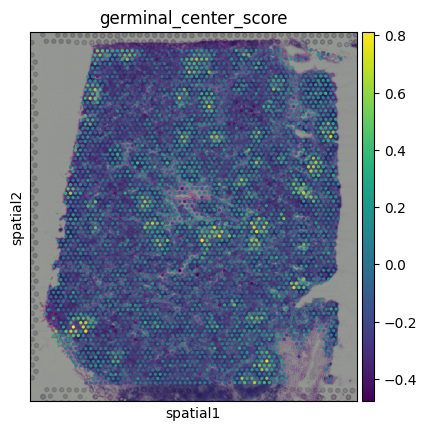

In [11]:
sc.pl.spatial(adata, color="germinal_center_score", cmap="viridis")

## Step 8 — verify_lock: catching silent data changes

Simulates what happens if a file gets modified outside this workflow
(e.g. a re-run with different parameters overwrites the file, or an
external script touches it) — this is the check you'd run when debugging
an unexpected result, per Step F of the original toolkit.

In [12]:
import os

path = os.path.join(pl.base_dir, "lymph_node_scored.h5ad")
with open(path, "ab") as f:
    f.write(b"\x00\x00\x00")  # simulate an external, undocumented change

check = pl.verify_lock("lymph_node_scored.h5ad")
print("Lock intact:", check.ok)

'lymph_node_scored.h5ad': CHANGED. Investigate data before touching code.
Lock intact: False


## Step 9 — freeze the environment

One-time per project; produces a `requirements.txt` snapshot for exact
reproducibility of the software environment.

In [13]:
pl.freeze_requirements()

Library versions frozen to lymph_node_demo/provenance/requirements.txt.


LockResult(ok=True, message='Library versions frozen to lymph_node_demo/provenance/requirements.txt.', path='lymph_node_demo/provenance/requirements.txt', size_mb=None, extra={})

## Summary

This notebook demonstrated the full `provlock` workflow on a real, fresh,
public spatial transcriptomics dataset:
- checksum-locked raw and scored AnnData checkpoints (with size-aware
  compression for the counts layer)
- checksum-locked tabular QC output
- group-label validation before statistics
- detection of silent external file changes
- environment freezing for reproducibility

No results here are claimed as novel biology — the germinal-center score
uses an established marker set, solely to exercise the tool end to end.
